# Notebook 01 — Packet-Counter Reconstruction
**Thesis §4.2 | Input:** `data/0_cleaned_dataset_Obiri_2025_v2.csv` | **Output:** `data/1_reconstructed.csv`

---

## What this notebook does

Implements the packet-counter reconstruction pipeline described in §4.2 of the thesis.
Every step follows the methodology order and maps to a specific thesis subsection.

| Step | Thesis section | Description |
|------|---------------|-------------|
| 0 | — | Imports, paths, plot style |
| 1 | §4.1 | Load and sort raw dataset |
| 2 | §4.2.1 | Reconstruction algorithm — frame losses and firmware drops |
| 3 | §4.2.2 | Counter reset detection |
| 4 | §4.2.1 | Counter divergence — p_count vs f_count (Fig 01_a) |
| 5 | §4.2.3 | Infrastructure outage detection — two-level synchronous detector |
| 6 | §4.2.4 | Loss classification (Fig 01_c) |
| 7 | §4.2.5 | PDR decomposition — three metrics (Fig 01_d) |
| 8 | §4.2.5 | Per-device loss breakdown |
| 9 | — | Save reconstructed dataset |

**Primary output column:** `mac_to_radio_loss` — packets that entered the air but never arrived.
Used as the loss metric in all downstream event-conditioned analysis (Notebooks 02 and 03).


## 0 · Imports & Paths

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path('../data')
FIG_DIR  = Path('../figures')
FIG_DIR.mkdir(exist_ok=True)

RAW_CSV = DATA_DIR / '0_cleaned_dataset_Obiri_2025_v2.csv'
OUT_CSV = DATA_DIR / '1_reconstructed.csv'

# Consistent plot style across all notebooks
plt.rcParams.update({
    'font.family': 'serif', 'font.size': 10, 'axes.titlesize': 11,
    'axes.labelsize': 10, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'figure.dpi': 150, 'savefig.dpi': 300,
    'savefig.bbox': 'tight', 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
})

# Colour palette — consistent across all notebooks
C = {
    'blue': '#0077BB', 'orange': '#EE7733', 'green': '#009988',
    'red': '#CC3311', 'purple': '#AA3377', 'navy': '#004488',
    'grey': '#BBBBBB', 'brown': '#882255',
}
DEVICE_COLORS = [C['blue'], C['orange'], C['green'], C['red'], C['purple'], C['navy']]

def save_fig(fig, name):
    fig.savefig(FIG_DIR / f'{name}.pdf')
    fig.savefig(FIG_DIR / f'{name}.png')
    print(f'  Saved: figures/{name}')
    plt.show()

print(f'Ready. Data    → {DATA_DIR.resolve()}')
print(f'       Figures → {FIG_DIR.resolve()}')

Ready. Data    → D:\Thesis\lorawan_master_thesis\data
       Figures → D:\Thesis\lorawan_master_thesis\figures


## 1 · Load & Sort  *(§4.1)*

Timestamps parsed as UTC to avoid daylight saving time ambiguity.
Rows sorted per device by time — export order from InfluxDB is not guaranteed.


In [17]:
df = pd.read_csv(RAW_CSV)
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.sort_values(['device_id', 'time']).reset_index(drop=True)

print(f'Rows    : {len(df):,}')
print(f'Devices : {sorted(df["device_id"].unique())}')
print(f'Period  : {df["time"].min().date()} → {df["time"].max().date()}')
print(f'SF range: SF{int(df["SF"].min())}–SF{int(df["SF"].max())}')
print()

print(f'{"Device":<10} {"Rows":>12} {"% of total":>12}')
print('-' * 36)
for dev, g in df.groupby('device_id'):
    n = len(g)
    print(f'{dev:<10} {n:>12,} {n/len(df)*100:>11.2f}%')
print('-' * 36)
print(f'{"Total":<10} {len(df):>12,} {"100.00%":>12}')

Rows    : 2,634,930
Devices : ['ED0', 'ED1', 'ED2', 'ED3', 'ED4', 'ED5']
Period  : 2024-10-01 → 2025-09-30
SF range: SF7–SF12

Device             Rows   % of total
------------------------------------
ED0             440,166       16.71%
ED1             434,548       16.49%
ED2             440,920       16.73%
ED3             433,579       16.46%
ED4             435,416       16.52%
ED5             450,301       17.09%
------------------------------------
Total         2,634,930      100.00%


## 2 · Reconstruction Algorithm  *(§4.2.1)*

`f_count` corresponds to **FCntUp** in the LoRaWAN specification — maintained by the
end-device, incremented with each uplink transmission. A gap in consecutive `f_count`
values encodes frames that left the device but never arrived at the network server.

`p_count` is written by the device firmware for every scheduled packet regardless of
whether the MAC layer transmits it. The difference `Δp − Δf` reveals packets dropped
before the radio fired — hereafter **firmware drops**.

| Output column | Meaning |
|---------------|---------|
| `mac_to_radio_loss` | $N_{\text{frame-loss}}$ — packets that entered the air but never arrived (**primary metric**) |
| `app_to_mac_drop` | $N_{\text{mac-silence}}$ — firmware drops before radio transmission |
| `total_tx_radio` | $1 + N_{\text{frame-loss}}$ — radio attempts (used in statistical tests, Notebook 03) |
| `total_tx` | $1 + N_{\text{frame-loss}} + N_{\text{mac-silence}}$ — all scheduled transmissions |


In [18]:
def reconstruct(grp):
    """
    Reconstruct frame losses and firmware drops for one device.
    Rows must be sorted by time (guaranteed by Cell 1).
    Reset intervals (delta_f < 0) are flagged and zeroed — the true
    loss count during a device reboot is unrecoverable from the counter alone.
    """
    grp     = grp.copy().reset_index(drop=True)
    delta_f = grp['f_count'].diff()
    delta_p = grp['p_count'].diff()

    is_reset = delta_f < 0                       # device rebooted — f_count reset to zero

    mac_loss = (delta_f - 1).clip(lower=0)       # N_frame-loss: transmissions that never arrived
    mac_loss[is_reset] = 0                       # reset intervals carry no loss information
    mac_loss.iloc[0]   = 0                       # first row has no predecessor

    app_drop = (delta_p - delta_f).clip(lower=0) # N_mac-silence: firmware drops before radio
    app_drop[is_reset] = 0
    app_drop.iloc[0]   = 0

    grp['mac_to_radio_loss'] = mac_loss.astype(int)
    grp['app_to_mac_drop']   = app_drop.astype(int)
    grp['total_tx_radio']    = 1 + grp['mac_to_radio_loss']  # radio attempts only
    grp['total_tx']          = 1 + grp['mac_to_radio_loss'] + grp['app_to_mac_drop']
    grp['is_reset']          = is_reset.fillna(False)
    return grp


device_ids = df['device_id'].copy()
df = df.groupby('device_id', group_keys=False).apply(reconstruct)
df['device_id'] = device_ids.values
df = df.reset_index(drop=True)

print('Reconstruction complete.')
print(f'  mac_to_radio_loss total : {df["mac_to_radio_loss"].sum():,}')
print(f'  app_to_mac_drop total   : {df["app_to_mac_drop"].sum():,}')

Reconstruction complete.
  mac_to_radio_loss total : 259,244
  app_to_mac_drop total   : 251,370


## 3 · Counter Reset Detection  *(§4.2.2)*

A device reboot resets `f_count` to zero, producing a large negative `Δf`.
Without handling, such an interval would inflate `mac_to_radio_loss` by thousands.
Every interval where `Δf < 0` is flagged as a reset, its loss forced to zero,
and excluded from all computations.


In [19]:
# Reset count per device — confirms reboots were rare
print(f'{"Device":<10} {"Resets":>8}')
print('-' * 20)
for dev, g in df.groupby('device_id'):
    print(f'{dev:<10} {int(g["is_reset"].sum()):>8}')
print('-' * 20)
print(f'{"Total":<10} {int(df["is_reset"].sum()):>8}')
print()
print('Reset intervals: mac_to_radio_loss set to 0, excluded from all loss computations.')

Device       Resets
--------------------
ED0               8
ED1               3
ED2               3
ED3               6
ED4               2
ED5               5
--------------------
Total            27

Reset intervals: mac_to_radio_loss set to 0, excluded from all loss computations.


## 4 · Counter Divergence: p_count vs f_count  *(§4.2.1 — Fig 01_a)*

`p_count` consistently exceeds `f_count` across all devices, confirming systematic
firmware-level packet dropping. The divergence (~10% mean) is attributable to two
mechanisms: duty cycle enforcement under ETSI EN 300 220 (SF11/SF12) and spreading
factor rotation artefacts. Since these drops reflect firmware behaviour rather than
radio-channel conditions, `f_count` is used exclusively as the reconstruction counter.


In [20]:
# Divergence between p_count and f_count — one row per device
div = df.groupby('device_id').agg(
    p_range=('p_count', lambda x: x.max() - x.min()),
    f_range=('f_count', lambda x: x.max() - x.min()),
).reset_index()
div['divergence'] = div['p_range'] - div['f_range']
div['pct']        = (div['divergence'] / div['p_range'] * 100).round(1)
mean_pct          = div['pct'].mean()

print(f'{"Device":<8} {"p_range":>10} {"f_range":>10} {"divergence":>12} {"drop rate":>10}')
print('-' * 56)
for _, row in div.iterrows():
    print(f'{row["device_id"]:<8} {int(row["p_range"]):>10,} '
          f'{int(row["f_range"]):>10,} {int(row["divergence"]):>12,} {row["pct"]:>9.1f}%')
print(f'\nDeployment-wide mean drop rate: {mean_pct:.1f}%')

Device      p_range    f_range   divergence  drop rate
--------------------------------------------------------
ED0         203,893    183,833       20,060       9.8%
ED1         363,580    322,405       41,175      11.3%
ED2         363,603    325,311       38,292      10.5%
ED3         251,676    223,787       27,889      11.1%
ED4         363,569    322,427       41,142      11.3%
ED5         363,710    331,373       32,337       8.9%

Deployment-wide mean drop rate: 10.5%


  Saved: figures/01_a_counter_divergence


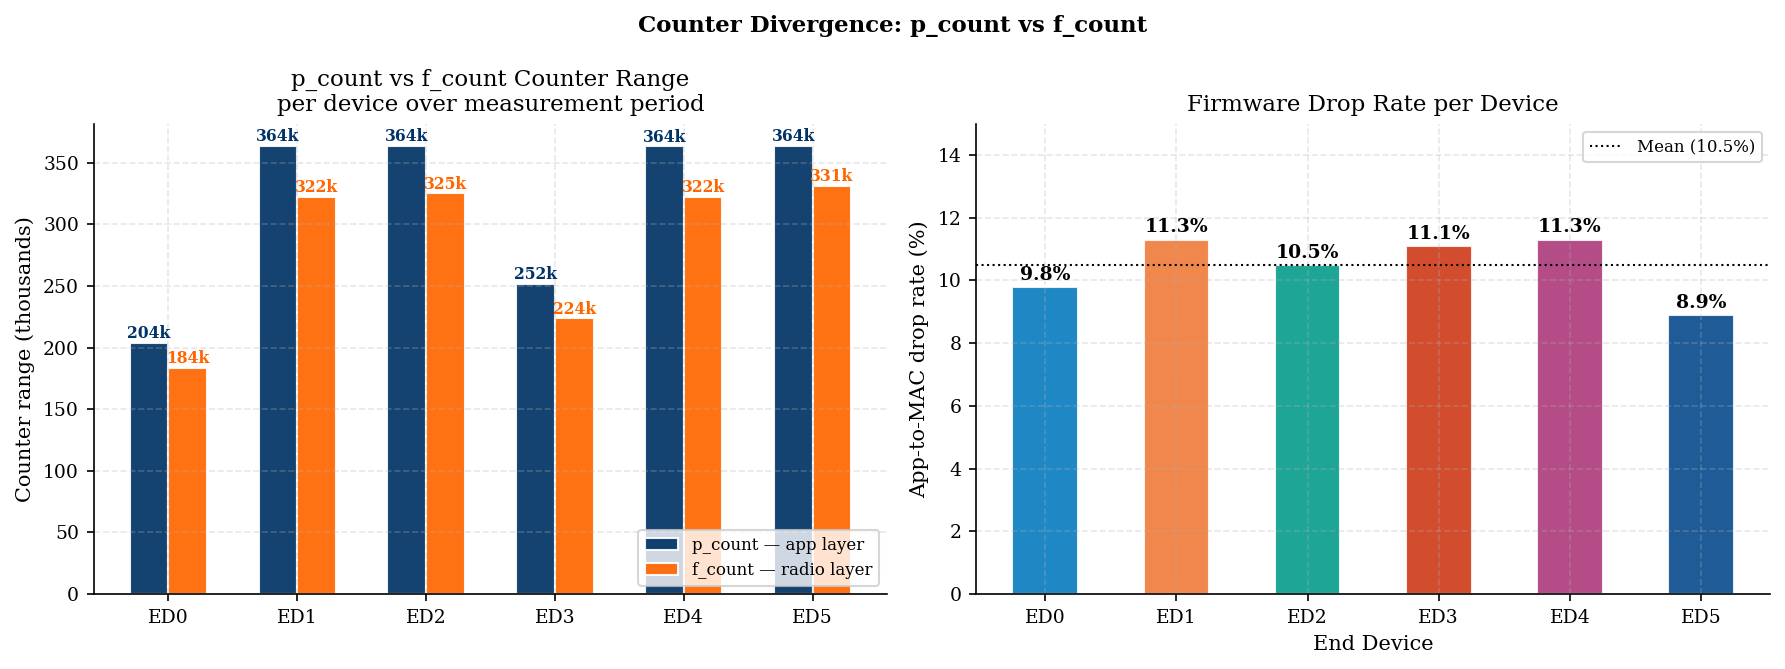

In [21]:
# Fig 01_a — p_count vs f_count divergence per device
DEVICES_D = div['device_id'].tolist()
x = np.arange(len(DEVICES_D))
w = 0.3

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left panel — raw counter ranges confirming p_count always exceeds f_count
b1 = axes[0].bar(x - w/2, div['p_range']/1000, w, color='#003366',
                 alpha=0.92, edgecolor='white', label='p_count — app layer')
b2 = axes[0].bar(x + w/2, div['f_range']/1000, w, color='#FF6600',
                 alpha=0.92, edgecolor='white', label='f_count — radio layer')
for bar, v in zip(b1, div['p_range']/1000):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.5,
                 f'{v:.0f}k', ha='center', va='bottom', fontsize=7.5,
                 color='#003366', fontweight='bold')
for bar, v in zip(b2, div['f_range']/1000):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.5,
                 f'{v:.0f}k', ha='center', va='bottom', fontsize=7.5,
                 color='#FF6600', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(DEVICES_D)
axes[0].set_ylabel('Counter range (thousands)')
axes[0].set_title('p_count vs f_count Counter Range\nper device over measurement period')
axes[0].legend(fontsize=8, loc='lower right')

# Right panel — firmware drop rate per device
bars = axes[1].bar(DEVICES_D, div['pct'],
                   color=DEVICE_COLORS[:len(DEVICES_D)], width=0.5,
                   alpha=0.88, edgecolor='white')
for bar, v in zip(bars, div['pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.1,
                 f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].axhline(y=mean_pct, color='black', lw=1.0, ls=':',
                label=f'Mean ({mean_pct:.1f}%)')
axes[1].set_ylabel('App-to-MAC drop rate (%)')
axes[1].set_xlabel('End Device')
axes[1].set_title('Firmware Drop Rate per Device')
axes[1].set_ylim(0, 15)
axes[1].legend(fontsize=8)

fig.suptitle('Counter Divergence: p_count vs f_count', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '01_a_counter_divergence')

## 5 · Infrastructure Outage Detection  *(§4.2.3)*

Two-level detector:
1. **Single-device threshold:** flag intervals with `mac_to_radio_loss > θ` (θ = 10, i.e. 10-minute silence)
2. **Multi-device synchronous confirmation:** confirm only windows where all 6 devices simultaneously exceed θ within 5 minutes — six independent radio links cannot all fail simultaneously under normal channel conditions


In [22]:
THETA = 10   # 10 consecutive losses = 10-minute silence at 60s TX interval

# ── Step 1: single-device flag ────────────────────────────────────────────────
df['is_outage'] = df['mac_to_radio_loss'] > THETA

# ── Step 2: multi-device synchronous confirmation ────────────────────────────
df['time_bin'] = df['time'].dt.floor('5min')

window_device_counts = (
    df[df['is_outage']]
    .groupby('time_bin')['device_id']
    .nunique()
    .reset_index(name='n_devices')
)

n_devices_total   = df['device_id'].nunique()
confirmed_windows = set(
    window_device_counts[window_device_counts['n_devices'] == n_devices_total]['time_bin']
)

# Re-flag — only intervals in confirmed windows retain is_outage = True
df['is_outage'] = df['time_bin'].isin(confirmed_windows) & (df['mac_to_radio_loss'] > THETA)
df = df.drop(columns=['time_bin'])

print(f'Outage threshold θ       : {THETA}')
print(f'Outage intervals flagged : {df["is_outage"].sum():,}')
print()

# ── Outage event summary ──────────────────────────────────────────────────────
large = df[df['is_outage']][['device_id', 'time', 'mac_to_radio_loss']].copy()
large['date']  = large['time'].dt.date
dates_map      = {d: i+1 for i, d in enumerate(sorted(large['date'].unique()))}
large['event'] = large['date'].map(dates_map)

summary = large.groupby('event').agg(
    date       = ('date',             'first'),
    n_devices  = ('device_id',        'nunique'),
    total_lost = ('mac_to_radio_loss', 'sum'),
    max_loss   = ('mac_to_radio_loss', 'max'),
).reset_index()
summary['duration_hrs'] = (summary['max_loss'] * 60 / 3600).round(2)

print(f'{"Ev":^4} {"Date":^12} {"Dur(h)":^8} {"N":^4} {"Total Lost":^12}')
print('-' * 46)
for _, row in summary.iterrows():
    print(f'{int(row["event"]):^4} {str(row["date"]):^12} '
          f'{row["duration_hrs"]:^8.2f} '
          f'{int(row["n_devices"]):^4} '
          f'{int(row["total_lost"]):^12,}')

print(f'\nConfirmed outage events  : {len(summary)}')
print(f'Total outage intervals   : {df["is_outage"].sum():,}')
print(f'Total packets lost       : {large["mac_to_radio_loss"].sum():,}')

Outage threshold θ       : 10
Outage intervals flagged : 240

 Ev      Date      Dur(h)   N    Total Lost 
----------------------------------------------
 1    2024-10-10    4.52    6      1,284    
 2    2024-10-11    1.12    6       619     
 3    2024-10-13   15.02    6      5,271    
 4    2024-10-15    0.43    6       147     
 5    2024-10-16    0.83    6       287     
 6    2024-10-17    1.53    6       518     
 7    2024-10-23    1.40    6       951     
 8    2024-10-25    0.62    6       382     
 9    2024-10-30    7.28    6      2,489    
 10   2024-11-26    0.52    6       180     
 11   2024-12-17    0.63    6       205     
 12   2025-01-25    0.77    6       150     
 13   2025-01-27    3.65    6      1,299    
 14   2025-02-25   184.22   6      64,954   
 15   2025-02-26    5.18    6      3,995    
 16   2025-03-11    0.60    6       208     
 17   2025-03-29    9.28    6      3,255    
 18   2025-04-07    3.35    6      1,162    
 19   2025-05-20   16.80    6      5

## 6 · Loss Classification  *(§4.2.4 — Fig 01_c)*

The 2,634,930 intervals decompose into four categories accounting for all 3,101,814
scheduled transmissions:

| Category | Condition | Role |
|----------|-----------|------|
| Clean reception | `mac_to_radio_loss = 0`, `is_outage = False` | Successfully received |
| Firmware drops | `app_to_mac_drop > 0` | Dropped before radio — excluded from analysis |
| Link losses | `1 ≤ mac_to_radio_loss ≤ θ`, `is_outage = False` | **Primary analysis target** |
| Infrastructure outages | `is_outage = True` | Excluded from event analysis |

$\mathcal{D}_{\text{link}}$ = all non-outage intervals, referred to as `df_link`.


In [23]:
# Vectorised zone classification
df['loss_zone'] = np.select(
    [df['is_outage'], df['mac_to_radio_loss'] == 0],
    ['outage', 'no_loss'],
    default='radio_loss'
)

# ── Interval counts ───────────────────────────────────────────────────────────
counts = df['loss_zone'].value_counts()
print(f'{"Zone":<15} {"Intervals":>12} {"Pct":>8}')
print('-' * 38)
for zone in ['no_loss', 'radio_loss', 'outage']:
    cnt = counts.get(zone, 0)
    print(f'{zone:<15} {cnt:>12,} {cnt/len(df)*100:>7.2f}%')
print('-' * 38)
print(f'{"Total":<15} {len(df):>12,} {"100.00%":>8}')
print()

# ── Packet accounting ─────────────────────────────────────────────────────────
clean_pkts  = df[df['loss_zone'] == 'no_loss'].shape[0]
fw_pkts     = int(df['app_to_mac_drop'].sum())
link_pkts   = int(df[df['loss_zone'] == 'radio_loss']['mac_to_radio_loss'].sum())
outage_pkts = int(df[df['is_outage']]['mac_to_radio_loss'].sum())
total_pkts  = clean_pkts + fw_pkts + link_pkts + outage_pkts

print(f'{"Category":<22} {"Packets":>12} {"Pct":>8}')
print('-' * 44)
for label, val in [('Clean received',       clean_pkts),
                   ('Firmware drops',        fw_pkts),
                   ('Link losses',           link_pkts),
                   ('Infrastructure outages',outage_pkts)]:
    print(f'{label:<22} {val:>12,} {val/total_pkts*100:>7.2f}%')
print('-' * 44)
print(f'{"Total scheduled":<22} {total_pkts:>12,} {"100.00%":>8}')
print()
print(f'df_link (non-outage) : {(~df["is_outage"]).sum():,} rows')

Zone               Intervals      Pct
--------------------------------------
no_loss            2,591,200   98.34%
radio_loss            43,490    1.65%
outage                   240    0.01%
--------------------------------------
Total              2,634,930  100.00%

Category                    Packets      Pct
--------------------------------------------
Clean received            2,591,200   83.54%
Firmware drops              251,370    8.10%
Link losses                 155,505    5.01%
Infrastructure outages      103,739    3.34%
--------------------------------------------
Total scheduled           3,101,814  100.00%

df_link (non-outage) : 2,634,690 rows


  Saved: figures/01_b_loss_classification


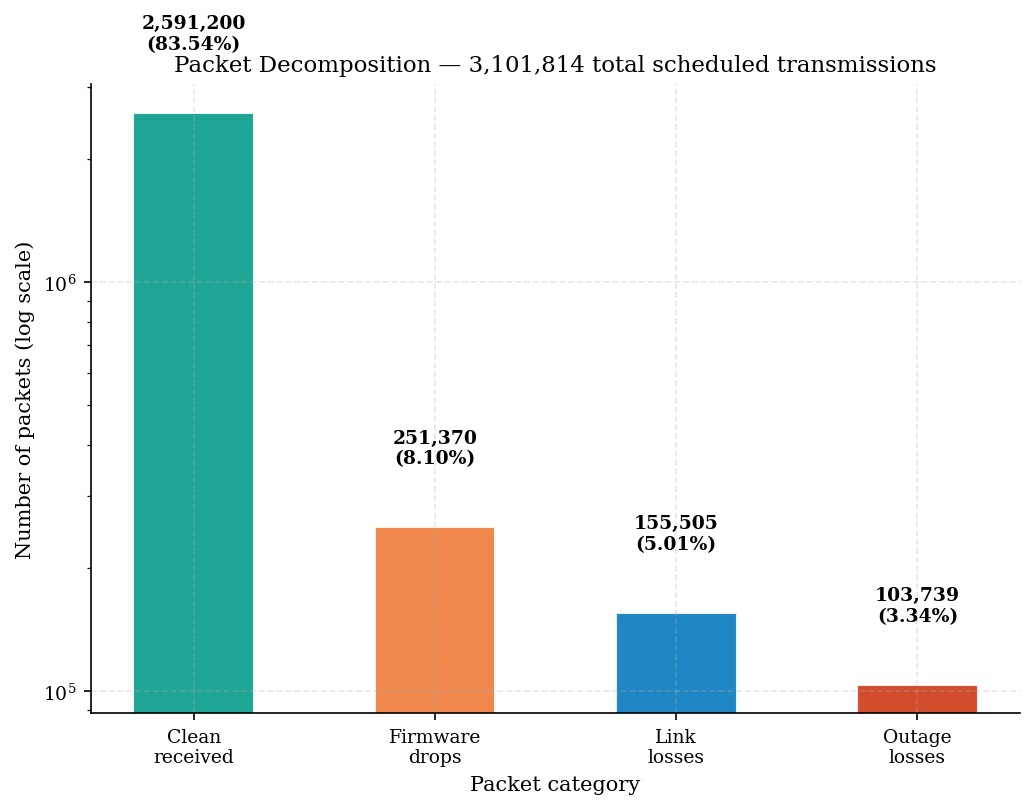

In [24]:
# Fig 01_c — Packet decomposition (single panel)
pkt_labels  = ['Clean\nreceived', 'Firmware\ndrops', 'Link\nlosses', 'Outage\nlosses']
pkt_counts  = [clean_pkts, fw_pkts, link_pkts, outage_pkts]
pkt_colors  = [C['green'], C['orange'], C['blue'], C['red']]
pkt_pcts    = [v / total_pkts * 100 for v in pkt_counts]

fig, ax = plt.subplots(figsize=(7, 5.5))

bars = ax.bar(pkt_labels, pkt_counts, color=pkt_colors,
              width=0.5, alpha=0.88, edgecolor='white')
ax.set_yscale('log')
for bar, cnt, pct in zip(bars, pkt_counts, pkt_pcts):
    ax.text(bar.get_x() + bar.get_width() / 2, cnt * 1.4,
            f'{cnt:,}\n({pct:.2f}%)',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('Number of packets (log scale)')
ax.set_xlabel('Packet category')
ax.set_title(f'Packet Decomposition — {total_pkts:,} total scheduled transmissions')

fig.tight_layout()
save_fig(fig, '01_b_loss_classification')

## 7 · PDR Decomposition  *(§4.2.5 — Fig 01_d)*

Three PDR metrics, each isolating a different layer of the transmission pipeline:

| Metric | Losses included | Interpretation |
|--------|----------------|----------------|
| `PDR_system` | Firmware drops + link losses + outages | Application-layer reliability |
| `PDR_link+outage` | Link losses + outages | Radio layer before outage filtering |
| `PDR_link` | Link losses only | **Primary metric** — true radio-channel reliability |

`PDR_link` is used in all event-conditioned analysis in Notebook 03.


In [25]:
total_rx          = len(df)
total_app_drops   = int(df['app_to_mac_drop'].sum())
total_radio_lost  = int(df['mac_to_radio_loss'].sum())

df_link           = df[~df['is_outage']]
total_link_lost   = int(df_link['mac_to_radio_loss'].sum())

pdr_system        = total_rx / (total_rx + total_app_drops + total_radio_lost) * 100
pdr_link_outage   = total_rx / (total_rx + total_radio_lost) * 100
pdr_link          = len(df_link) / (len(df_link) + total_link_lost) * 100

print(f'PDR_system       : {pdr_system:.2f}%   (firmware drops + all radio losses)')
print(f'PDR_link+outage  : {pdr_link_outage:.2f}%   (radio losses, outages included)')
print(f'PDR_link         : {pdr_link:.2f}%   (radio losses, outages excluded)')
print()
print(f'Firmware drops account for  : {pdr_link_outage - pdr_system:.2f} pp')
print(f'Outage removal accounts for : {pdr_link - pdr_link_outage:.2f} pp')
print()
print('Per-device PDR_link:')
for dev, g in df_link.groupby('device_id'):
    rx   = len(g)
    lost = int(g['mac_to_radio_loss'].sum())
    dist = int(df[df['device_id'] == dev]['distance'].iloc[0])
    print(f'  {dev} ({dist}m): {rx/(rx+lost)*100:.2f}%')

PDR_system       : 83.77%   (firmware drops + all radio losses)
PDR_link+outage  : 91.04%   (radio losses, outages included)
PDR_link         : 94.43%   (radio losses, outages excluded)

Firmware drops account for  : 7.28 pp
Outage removal accounts for : 3.38 pp

Per-device PDR_link:
  ED0 (10m): 94.57%
  ED1 (8m): 93.92%
  ED2 (23m): 94.69%
  ED3 (18m): 93.66%
  ED4 (37m): 94.24%
  ED5 (40m): 95.46%


## 8 · Per-Device Loss Breakdown  *(§4.2.5)*

Full loss decomposition per device. PDR_link values feed directly into the thesis results.

`Total scheduled = Received + Firmware drops + Link losses + Outage losses`


In [26]:
print(f'{"Dev":<6} {"Dist":^6} {"CW":^4} {"WW":^4} '
      f'{"Received":^10} {"FW Drops":^9} {"Outage":^9} {"Link Loss":^11} '
      f'{"PDR_sys":^9} {"PDR_l+o":^9} {"PDR_link":^10}')
print('-' * 105)

totals = {'rx': 0, 'fw': 0, 'outage': 0, 'link': 0}

for dev, g in df.groupby('device_id'):
    rx         = len(g)
    fw         = int(g['app_to_mac_drop'].sum())
    outage     = int(g[g['is_outage']]['mac_to_radio_loss'].sum())
    g_link     = g[~g['is_outage']]
    link       = int(g_link['mac_to_radio_loss'].sum())
    radio_lost = outage + link

    for k, v in [('rx', rx), ('fw', fw), ('outage', outage), ('link', link)]:
        totals[k] += v

    pdr_sys  = rx / (rx + fw + radio_lost) * 100
    pdr_lo   = rx / (rx + radio_lost) * 100
    pdr_lnk  = len(g_link) / (len(g_link) + link) * 100

    dist = int(g['distance'].iloc[0])
    cw   = int(g['c_walls'].iloc[0])
    ww   = int(g['w_walls'].iloc[0])

    print(f'{dev:<6} {dist:^6} {cw:^4} {ww:^4} '
          f'{rx:^10,} {fw:^9,} {outage:^9,} {link:^11,} '
          f'{pdr_sys:^9.2f} {pdr_lo:^9.2f} {pdr_lnk:^10.2f}')

print('-' * 105)
t          = totals
radio_lost = t['outage'] + t['link']
total_all  = t['rx'] + t['fw'] + radio_lost
print(f'{"Total":<6} {"":^6} {"":^4} {"":^4} '
      f'{t["rx"]:^10,} {t["fw"]:^9,} {t["outage"]:^9,} {t["link"]:^11,} '
      f'{t["rx"]/(t["rx"]+t["fw"]+radio_lost)*100:^9.2f} '
      f'{t["rx"]/(t["rx"]+radio_lost)*100:^9.2f} '
      f'{t["rx"]/(t["rx"]+t["link"])*100:^10.2f}')

Dev     Dist   CW   WW   Received  FW Drops   Outage    Link Loss   PDR_sys   PDR_l+o   PDR_link 
---------------------------------------------------------------------------------------------------------
ED0      10    0    0    440,166    39,670    17,372     25,268      84.25     91.17     94.57   
ED1      8     1    0    434,548    44,862    17,245     28,133      82.80     90.54     93.92   
ED2      23    0    2    440,920    42,083    17,106     24,716      84.01     91.34     94.69   
ED3      18    1    2    433,579    43,688    17,129     29,348      82.78     90.32     93.66   
ED4      37    0    5    435,416    45,534    17,197     26,627      82.97     90.86     94.24   
ED5      40    2    2    450,301    35,533    17,690     21,413      85.78     92.01     95.46   
---------------------------------------------------------------------------------------------------------
Total                   2,634,930   251,370   103,739    155,505     83.77     91.04     94.43   


  Saved: figures/01_c_pdr_decomposition_per_device


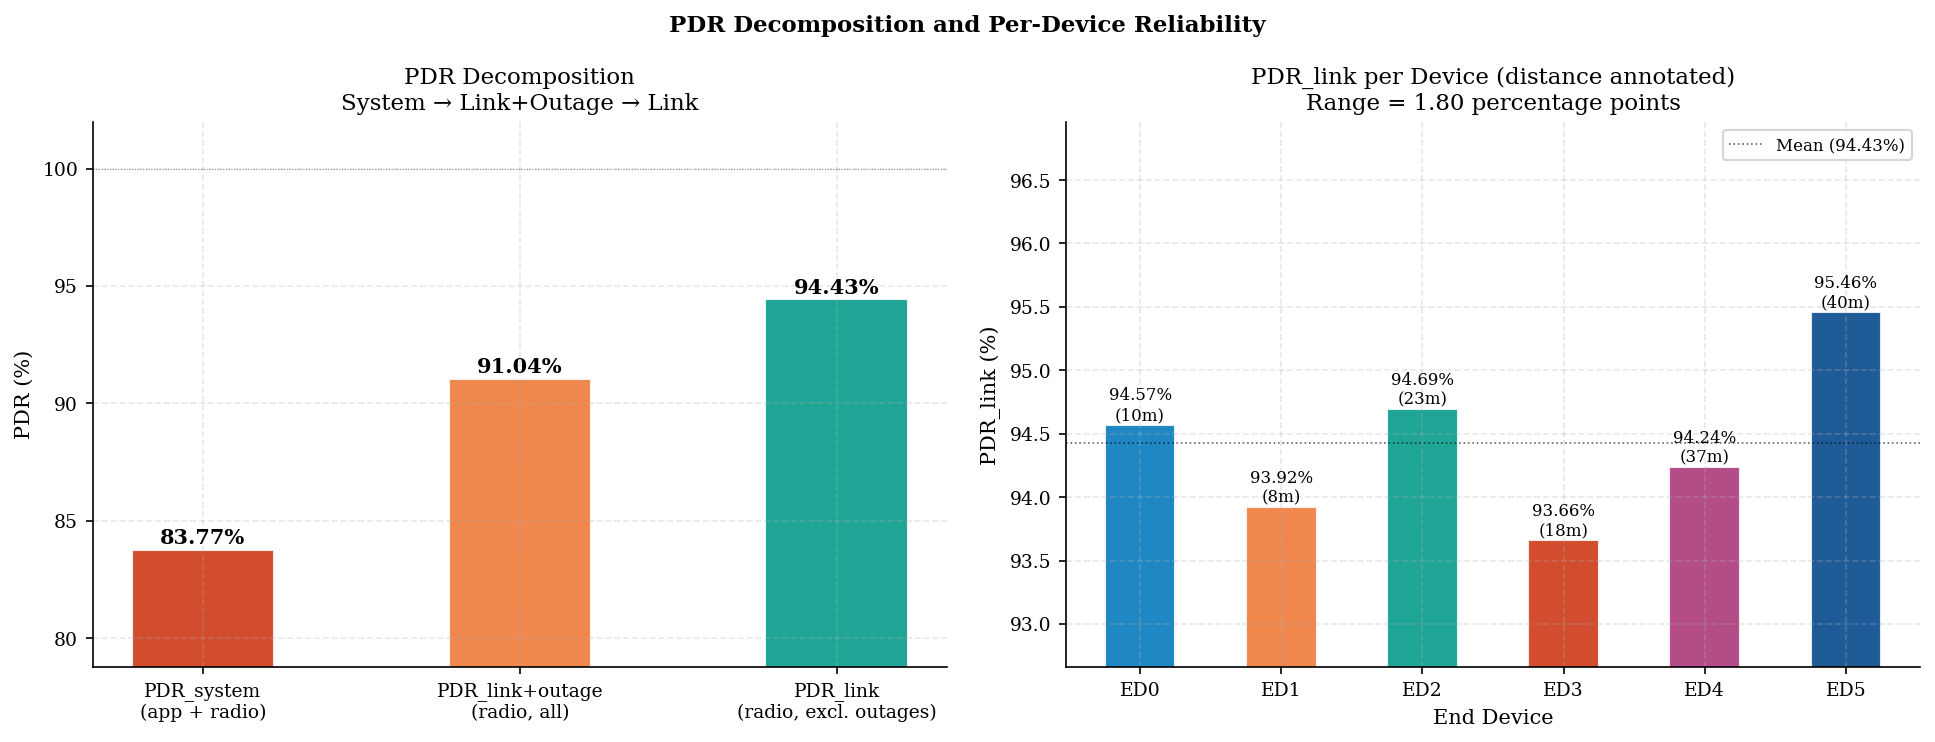

In [27]:
# Fig 01_d — PDR decomposition (left) + per-device PDR_link (right)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left panel — three PDR metrics
categories = ['PDR_system\n(app + radio)',
              'PDR_link+outage\n(radio, all)',
              'PDR_link\n(radio, excl. outages)']
values_v   = [pdr_system, pdr_link_outage, pdr_link]
colors_v   = [C['red'], C['orange'], C['green']]

bars = axes[0].bar(categories, values_v, color=colors_v,
                   width=0.45, alpha=0.88, edgecolor='white')
for bar, v in zip(bars, values_v):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.1,
                 f'{v:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_ylim(min(values_v) - 5, 102)
axes[0].set_ylabel('PDR (%)')
axes[0].axhline(y=100, color='grey', lw=0.5, ls=':')
axes[0].set_title('PDR Decomposition\nSystem → Link+Outage → Link')

# Right panel — PDR_link per device
DEVICES_P = sorted(df['device_id'].unique())
dev_pdrs, dev_dists = [], []
for dev in DEVICES_P:
    g    = df_link[df_link['device_id'] == dev]
    rx   = len(g)
    lost = int(g['mac_to_radio_loss'].sum())
    dev_pdrs.append(rx / (rx + lost) * 100)
    dev_dists.append(int(df[df['device_id'] == dev]['distance'].iloc[0]))

bars2 = axes[1].bar(DEVICES_P, dev_pdrs,
                    color=DEVICE_COLORS[:len(DEVICES_P)], width=0.5,
                    alpha=0.88, edgecolor='white')
for bar, v, d in zip(bars2, dev_pdrs, dev_dists):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.01,
                 f'{v:.2f}%\n({d}m)', ha='center', va='bottom', fontsize=8)
axes[1].axhline(y=pdr_link, color='black', lw=0.8, ls=':', alpha=0.6,
                label=f'Mean ({pdr_link:.2f}%)')
axes[1].set_ylabel('PDR_link (%)')
axes[1].set_xlabel('End Device')
axes[1].set_ylim(min(dev_pdrs) - 1, max(dev_pdrs) + 1.5)
axes[1].set_title(f'PDR_link per Device (distance annotated)\n'
                  f'Range = {max(dev_pdrs) - min(dev_pdrs):.2f} percentage points')
axes[1].legend(fontsize=8)

fig.suptitle('PDR Decomposition and Per-Device Reliability', fontsize=11, fontweight='bold')
fig.tight_layout()
save_fig(fig, '01_c_pdr_decomposition_per_device')

## 9 · Save  *(1_reconstructed.csv)*

Original columns preserved in order. Derived columns appended at the end.

| Group | Columns |
|-------|---------|
| Identifiers | `device_id`, `time` |
| Environmental | `co2`, `humidity`, `pm25`, `pressure`, `temperature` |
| Radio metrics | `rssi`, `snr`, `esp`, `SF`, `frequency`, `toa` |
| Spatial | `distance`, `c_walls`, `w_walls`, `exp_pl`, `n_power` |
| Raw counters | `f_count`, `p_count` |
| Derived | `mac_to_radio_loss`, `app_to_mac_drop`, `total_tx`, `total_tx_radio`, `is_reset`, `is_outage`, `loss_zone` |


In [28]:
original_cols = [
    'device_id', 'time',
    'co2', 'humidity', 'pm25', 'pressure', 'temperature',
    'rssi', 'snr', 'esp', 'SF', 'frequency', 'toa',
    'distance', 'c_walls', 'w_walls', 'exp_pl', 'n_power',
    'f_count', 'p_count',
]
derived_cols = [
    'mac_to_radio_loss',
    'app_to_mac_drop',
    'total_tx',
    'total_tx_radio',
    'is_reset',
    'is_outage',
    'loss_zone',
]

final_cols = (
    [c for c in original_cols if c in df.columns] +
    [c for c in derived_cols  if c in df.columns]
)
df = df[final_cols]

df.to_csv(OUT_CSV, index=False)
print(f'Saved : {OUT_CSV}')
print(f'Rows  : {len(df):,}')
print(f'Cols  : {len(df.columns)}')
print(f'Next  : 02_events.ipynb')

Saved : ..\data\1_reconstructed.csv
Rows  : 2,634,930
Cols  : 27
Next  : 02_events.ipynb
